# 05 — Modeling: Comparing Classifiers

Trains and compares several classifiers on `outputs/processed/combined_features.csv` (frequency-domain + statistical/temporal features, 1313 windows x 20 subjects), to predict which of the four phases (Relax, PhysicalStress, CognitiveStress, EmotionalStress) a window belongs to.

## Design decisions

| Decision | Choice | Why |
|---|---|---|
| Models compared | Logistic Regression, k-Nearest Neighbors, SVM (RBF), Random Forest, Gradient Boosting (`HistGradientBoostingClassifier`) | Spans simple/interpretable (linear, distance-based) to high-capacity (tree ensembles), matching what's standard in physiological stress-classification literature. |
| Evaluation protocol | 5-fold `StratifiedGroupKFold`, grouped by `subject_id` | A subject's windows must never appear in both train and test within a fold -- required given the overlapping 60s/30s windows (they share raw samples) and per-subject physiological baseline differences. Stratified so each fold keeps a similar class balance as far as the grouping constraint allows. |
| Primary metric | Macro-averaged F1 | Relax is ~54% of the data; plain accuracy would reward a model that just predicts Relax. Macro-F1 weighs all four classes equally. |
| Class imbalance handling | `class_weight='balanced'` (all models except k-NN, which has no such parameter) | Counteracts the same Relax-heavy imbalance at training time, not just at evaluation time. |
| Feature scaling | `StandardScaler` in every model's pipeline | Required for Logistic Regression/k-NN/SVM; harmless (a no-op on split quality) for the tree ensembles, so applying it uniformly keeps the code simple. |

Every window gets exactly one out-of-fold (OOF) prediction, made by a fold that never saw that window's subject during training. All reported metrics are computed on these OOF predictions -- equivalent to 5-fold cross-validation, reported as one clean evaluation per model rather than five separate ones.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42
CLASS_ORDER = ['Relax', 'PhysicalStress', 'CognitiveStress', 'EmotionalStress']

## Load features

In [2]:
features_df = pd.read_csv('../outputs/processed/combined_features.csv')

METADATA_COLUMNS = ['window_index', 'label', 'start_time', 'subject_id']
FEATURE_COLUMNS = [c for c in features_df.columns if c not in METADATA_COLUMNS]

X = features_df[FEATURE_COLUMNS]
y = features_df['label']
groups = features_df['subject_id']

print(f"Rows: {len(X)}, Features: {len(FEATURE_COLUMNS)}, Subjects: {groups.nunique()}")
print(f"NaN: {X.isna().sum().sum()}, Inf: {np.isinf(X.to_numpy()).sum()}")
print()
print(y.value_counts().reindex(CLASS_ORDER))

Rows: 1313, Features: 45, Subjects: 20
NaN: 0, Inf: 0

label
Relax              709
PhysicalStress     180
CognitiveStress    201
EmotionalStress    223
Name: count, dtype: int64


## Models

In [3]:
MODELS = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'k-Nearest Neighbors': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5)),
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
}

## Cross-validate every model

In [4]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}
for model_name, pipeline in MODELS.items():
    oof_predictions = pd.Series(index=X.index, dtype=object)
    fold_macro_f1 = []

    for train_idx, test_idx in cv.split(X, y, groups):
        pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
        fold_predictions = pipeline.predict(X.iloc[test_idx])
        oof_predictions.iloc[test_idx] = fold_predictions
        fold_macro_f1.append(f1_score(y.iloc[test_idx], fold_predictions, labels=CLASS_ORDER, average='macro'))

    results[model_name] = {
        'oof_predictions': oof_predictions,
        'fold_macro_f1_mean': float(np.mean(fold_macro_f1)),
        'fold_macro_f1_std': float(np.std(fold_macro_f1)),
        'oof_macro_f1': f1_score(y, oof_predictions, labels=CLASS_ORDER, average='macro'),
        'oof_accuracy': accuracy_score(y, oof_predictions),
    }
    r = results[model_name]
    print(f"{model_name:22s} fold macro-F1 = {r['fold_macro_f1_mean']:.3f} +/- {r['fold_macro_f1_std']:.3f}   "
          f"OOF macro-F1 = {r['oof_macro_f1']:.3f}   OOF accuracy = {r['oof_accuracy']:.3f}")

Logistic Regression    fold macro-F1 = 0.729 +/- 0.066   OOF macro-F1 = 0.731   OOF accuracy = 0.730


k-Nearest Neighbors    fold macro-F1 = 0.640 +/- 0.063   OOF macro-F1 = 0.642   OOF accuracy = 0.682


SVM (RBF)              fold macro-F1 = 0.724 +/- 0.077   OOF macro-F1 = 0.727   OOF accuracy = 0.724


Random Forest          fold macro-F1 = 0.761 +/- 0.083   OOF macro-F1 = 0.768   OOF accuracy = 0.786


Gradient Boosting      fold macro-F1 = 0.746 +/- 0.072   OOF macro-F1 = 0.756   OOF accuracy = 0.783


## Comparison table

In [5]:
summary_df = pd.DataFrame([
    {
        'model': name,
        'fold_macro_f1_mean': r['fold_macro_f1_mean'],
        'fold_macro_f1_std': r['fold_macro_f1_std'],
        'oof_macro_f1': r['oof_macro_f1'],
        'oof_accuracy': r['oof_accuracy'],
    }
    for name, r in results.items()
]).sort_values('oof_macro_f1', ascending=False).reset_index(drop=True)

summary_df

,model,fold_macro_f1_mean,fold_macro_f1_std,oof_macro_f1,oof_accuracy
0,Random Forest,0.761143,0.083297,0.768000,0.785986
1,Gradient Boosting,0.745933,0.072417,0.755781,0.782940
2,Logistic Regression,0.729159,0.066286,0.731172,0.730388
3,SVM (RBF),0.723579,0.076902,0.727192,0.723534
4,k-Nearest Neighbors,0.640034,0.063134,0.642194,0.682407


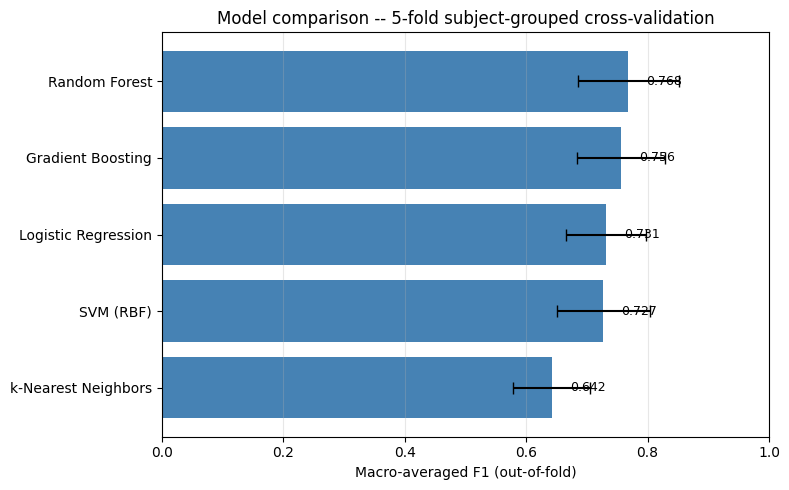

In [6]:
plot_df = summary_df.sort_values('oof_macro_f1')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(plot_df['model'], plot_df['oof_macro_f1'], xerr=plot_df['fold_macro_f1_std'],
                color='steelblue', capsize=4)
ax.set_xlabel('Macro-averaged F1 (out-of-fold)')
ax.set_xlim(0, 1)
ax.set_title('Model comparison -- 5-fold subject-grouped cross-validation')
ax.grid(axis='x', alpha=0.3)

for bar, value in zip(bars, plot_df['oof_macro_f1']):
    ax.text(min(value + 0.03, 0.97), bar.get_y() + bar.get_height() / 2, f'{value:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Per-class detail -- best model

In [7]:
best_model_name = summary_df.iloc[0]['model']
print(f"Best model: {best_model_name}\n")
print(classification_report(y, results[best_model_name]['oof_predictions'], labels=CLASS_ORDER, digits=3))

Best model: Random Forest

                 precision    recall  f1-score   support

          Relax      0.844     0.824     0.834       709
 PhysicalStress      0.940     0.961     0.951       180
CognitiveStress      0.728     0.746     0.737       201
EmotionalStress      0.541     0.561     0.551       223

       accuracy                          0.786      1313
      macro avg      0.763     0.773     0.768      1313
   weighted avg      0.788     0.786     0.787      1313



## Confusion matrices -- all models

Row-normalized (each row sums to 1): shows, for windows truly belonging to a given phase, what fraction the model predicted for each phase.

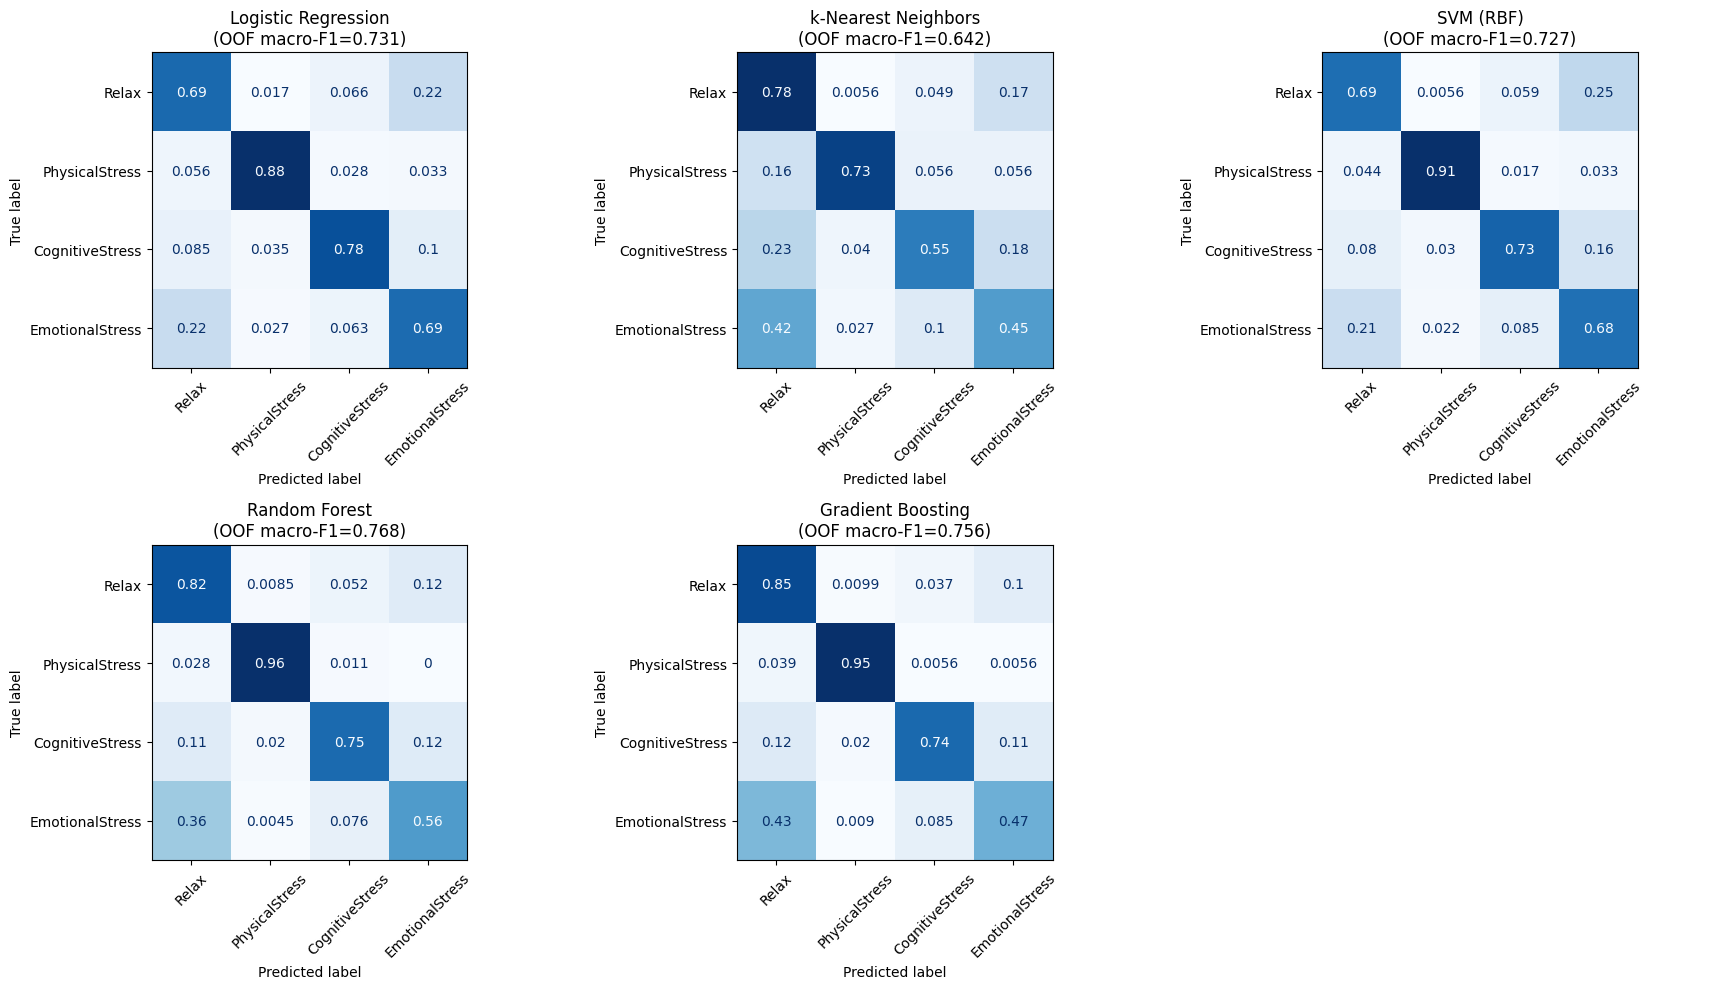

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, (model_name, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y, r['oof_predictions'], labels=CLASS_ORDER, normalize='true', cmap='Blues',
        ax=ax, colorbar=False, xticks_rotation=45,
    )
    ax.set_title(f"{model_name}\n(OOF macro-F1={r['oof_macro_f1']:.3f})")

for ax in axes[len(results):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Feature importance

Random Forest, refit on the full dataset -- this fit is for interpretability only, not a performance claim (those come from the cross-validation above). Answers the question flagged early in `thesis_notes.md`'s Classification Decisions: are temperature and SpO2 actually low-importance, as the time-domain analysis in notebook 01/02 expected?

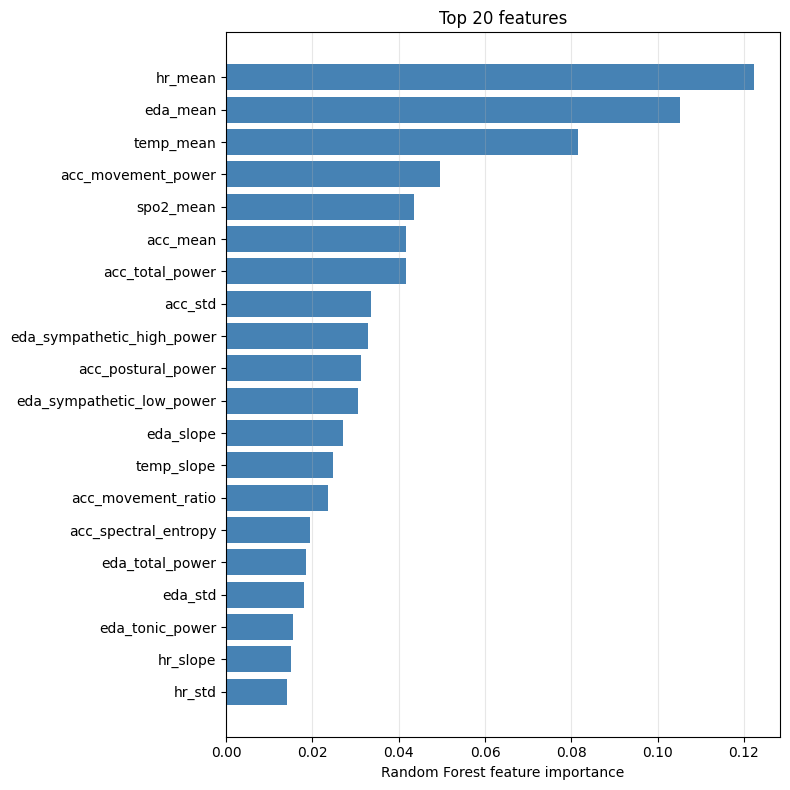

In [9]:
importance_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)),
])
importance_pipeline.fit(X, y)

importance_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'importance': importance_pipeline.named_steps['clf'].feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)
importance_df['rank'] = importance_df.index + 1

top_n = 20
plot_df = importance_df.head(top_n).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(plot_df['feature'], plot_df['importance'], color='steelblue')
ax.set_xlabel('Random Forest feature importance')
ax.set_title(f'Top {top_n} features')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
temp_spo2 = importance_df[importance_df['feature'].str.startswith(('temp_', 'spo2_'))]
print(f"temp_/spo2_ features occupy ranks {temp_spo2['rank'].min()}-{temp_spo2['rank'].max()} of {len(importance_df)}, "
      f"summing to {temp_spo2['importance'].sum() * 100:.1f}% of total importance "
      f"({len(temp_spo2)} features out of {len(importance_df)} total).")

temp_/spo2_ features occupy ranks 3-43 of 45, summing to 24.0% of total importance (14 features out of 45 total).


## Summary

In [11]:
print(f"Best model: {best_model_name}")
print(f"  OOF macro-F1 = {results[best_model_name]['oof_macro_f1']:.3f}")
print(f"  OOF accuracy = {results[best_model_name]['oof_accuracy']:.3f}")
print()
print("Top 5 most important features (Random Forest):")
print(importance_df[['rank', 'feature', 'importance']].head(5).to_string(index=False))

Best model: Random Forest
  OOF macro-F1 = 0.768
  OOF accuracy = 0.786

Top 5 most important features (Random Forest):
 rank            feature  importance
    1            hr_mean    0.122235
    2           eda_mean    0.105141
    3          temp_mean    0.081638
    4 acc_movement_power    0.049557
    5          spo2_mean    0.043620


## Limitations

- No hyperparameter tuning was done -- this is a baseline comparison at default (or lightly reasoned) parameters, not each model's ceiling performance.
- Only 20 subjects: `StratifiedGroupKFold` folds hold out 4 subjects at a time, so per-fold scores can be noisy; the fold mean/std reported above is a better estimate of variability than any single fold.
- k-Nearest Neighbors has no `class_weight` equivalent, so it doesn't get the same class-imbalance correction the other four models do.